# Phase Identification and Window Segmentation — AR-AIC Method

This notebook implements the complete phase detection and window segmentation pipeline using the **AR-AIC (Autoregressive-Akaike Information Criterion)** method. The pipeline processes seismic signals to identify P-wave, S-wave, and coda onsets, then segments each signal into four temporal windows for subsequent moment scaling analysis.

**Workflow:**
1. **Crustal velocity estimation** — Query CRUST1.0 model for depth-weighted v_P and v_S
2. **Theoretical arrival times** — Compute P/S arrivals using hypocentral distance
3. **Adaptive search windows** — Define distance-dependent windows to guide detection
4. **AR-AIC onset detection** — Detect P and S arrivals using ObsPy's AR-picker
5. **Coda onset detection** — Apply four methods (Rautian, Arias, Envelope, Median)
6. **Window segmentation** — Create four non-overlapping windows: pre-event, P-wave, S-wave, coda
7. **Quality control** — Validate detections (monotonicity, SNR, peak timing)

**Dataset:** Preprocessed signals from notebook `01b_signals` (baseline-corrected, unnormalized).

**Key reference:** Leonard & Kennett (1999) — AR-AIC method

**Outputs:**
- `df_full_{signal_type}_ar_pick.parquet` — Complete metadata with detected onsets
- `windowed_{signal_type}_{coda_method}_ar_pick.pkl` — Segmented signals (4 windows × 4 coda methods)
- Validation plots: onset detection, residuals, coda comparison, quality control

## 1. Imports and visualization settings

In [1]:
import sys
import pandas as pd
import numpy as np
import logging
from matplotlib import pyplot as plt
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / 'src'))
from IPython.display import display
import pickle
from src import (
    add_time_columns,
    convert_signals_to_dict,
    validate_signals_dict,
    add_crustal_velocities,
    add_theoretical_arrivals,
    set_plot_style,
    display_theoretical_arrivals_table,
    plot_crustal_velocities_vs_distance,
    plot_apparent_vs_crustal_velocities,
    plot_theoretical_arrivals,
    calculate_distance_thresholds,
    calculate_adaptive_windows,
    detect_onsets_arpick,
    plot_onset_detection_results,
    onset_detection_to_latex,
    coda_onset_comparison_to_latex,
    expand_to_component_level,
    add_coda_onsets_to_dataframe,
    plot_coda_onset_results,
    plot_coda_scatter_comparison,
    plot_bland_altman_comparison,
    plot_residuals_vs_distance,
    plot_pairwise_difference_histograms,
    plot_correlation_matrix_heatmap,
    compute_coda_method_statistics,
    segment_all_signals,
    plot_multiple_stations,
    quality_control_all_stations,
    print_quality_control_summary,
    print_detailed_failures,
    analyze_monotonicity_violations,
    print_violation_summary,
    plot_monotonicity_analysis,
    analyze_residuals_vs_violations,
    add_coda_end_to_dataframe,
    get_station_from_filename
)
colors = set_plot_style()
logging.basicConfig(level=logging.INFO, format="%(levelname)s | %(message)s")
logger = logging.getLogger()
def check(condition, message):
    if condition:
        logger.info(message)
    else:
        raise ValueError(message)
logger.info("Environment ready")

INFO | Environment ready


## 2. Configuration

Set `DATA_TYPE` to process acceleration, velocity, or displacement signals. The configuration automatically determines:
- Signal column name
- Physical units
- Peak ground motion columns (PGA/PGV/PGD)

This notebook processes all three signal types independently to compare phase detection performance across different kinematic quantities.

In [2]:
# CONFIGURATION
# EVENT_ID = 'INT-41004391'
EVENT_ID = 'IT-2009-0009'
DATA_TYPE = 'acceleration'  # Options: 'acceleration', 'velocity', 'displacement'

# Determine signal column name and units based on DATA_TYPE
if DATA_TYPE == 'acceleration':
    SIGNAL_COLUMN = 'acceleration'
    SIGNAL_UNIT = 'cm/s²'
    PEAK_COLUMN = 'PGA_CM/S^2'
    TIME_PEAK_COLUMN = 'TIME_PGA_S'
elif DATA_TYPE == 'velocity':
    SIGNAL_COLUMN = 'velocity'
    SIGNAL_UNIT = 'cm/s'
    PEAK_COLUMN = 'PGV_CM/S'
    TIME_PEAK_COLUMN = 'TIME_PGV_S'
elif DATA_TYPE == 'displacement':
    SIGNAL_COLUMN = 'displacement'
    SIGNAL_UNIT = 'cm'
    PEAK_COLUMN = 'PGD_CM'
    TIME_PEAK_COLUMN = 'TIME_PGD_S'
else:
    raise ValueError(f"Unknown DATA_TYPE: {DATA_TYPE}")

logger.info(f"Working with {DATA_TYPE} data")
logger.info(f"Signal column: {SIGNAL_COLUMN}")
logger.info(f"Peak column: {PEAK_COLUMN}")

INFO | Working with acceleration data
INFO | Signal column: acceleration
INFO | Peak column: PGA_CM/S^2


## 3. Data Loading

Load preprocessed signals and metadata from previous notebooks:
- **Signals:** Baseline-corrected but **not normalized** (preserves physical amplitudes for AR-AIC)
- **Metadata:** Station coordinates, epicentral distances, event parameters

**Note:** AR-AIC requires unnormalized signals because the method relies on absolute amplitude changes to detect onsets.

In [3]:
# Get project root
NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent

# Define all paths from project root with DATA_TYPE subdirectories
METADATA_PROCESSED = PROJECT_ROOT / 'data' / 'processed' / EVENT_ID / '01a_metadata' / DATA_TYPE
SIGNALS_PROCESSED_IMPORT = PROJECT_ROOT / 'data' / 'processed' / EVENT_ID / '01b_signals' / DATA_TYPE
SIGNALS_PROCESSED_EXPORT = PROJECT_ROOT / 'data' / 'processed' / EVENT_ID / '03a_phase_identification_ar_pick' / DATA_TYPE
FIGURES_DIR = PROJECT_ROOT / 'figures' / EVENT_ID / '03a_phase_identification_ar_pick' / DATA_TYPE
LATEX_TABLES_DIR = PROJECT_ROOT / 'data' / 'processed' / EVENT_ID / 'latex_tables' / DATA_TYPE

# Create output directories
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
METADATA_PROCESSED.mkdir(parents=True, exist_ok=True)
SIGNALS_PROCESSED_IMPORT.mkdir(parents=True, exist_ok=True)
SIGNALS_PROCESSED_EXPORT.mkdir(parents=True, exist_ok=True)
LATEX_TABLES_DIR.mkdir(parents=True, exist_ok=True)

check(FIGURES_DIR.exists(), f"Figures directory ready: {FIGURES_DIR}")
check(SIGNALS_PROCESSED_EXPORT.exists(), f"Exported signals directory ready: {SIGNALS_PROCESSED_EXPORT}")
check(LATEX_TABLES_DIR.exists(), f"LaTeX tables directory ready: {LATEX_TABLES_DIR}")
check(METADATA_PROCESSED.exists(), f"Processed metadata directory ready: {METADATA_PROCESSED}")
check(SIGNALS_PROCESSED_IMPORT.exists(), f"Processed signals directory ready: {SIGNALS_PROCESSED_IMPORT}")

# Load metadata
logger.info(f"Loading {DATA_TYPE} metadata...")
df_meta = pd.read_parquet(METADATA_PROCESSED / f'metadata_clean_{DATA_TYPE[:3]}.parquet')
check(df_meta is not None, "Metadata loaded successfully")
check(len(df_meta) > 0, "Metadata dataframe is not empty")
logger.info(f"Metadata loaded, shape: {df_meta.shape}")

# Load signals
logger.info(f"Loading {DATA_TYPE} signals...")
df_signals = pd.read_parquet(SIGNALS_PROCESSED_IMPORT / f'{DATA_TYPE[:3]}_preprocessed_scaling.parquet')
check(df_signals is not None, "Signals loaded successfully")
check(len(df_signals) > 0, "Signals dataframe is not empty")
logger.info(f"Signals loaded, shape: {df_signals.shape}")
logger.info(f"Unique files: {df_signals['file'].nunique()}")

INFO | Figures directory ready: /Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/figures/IT-2009-0009/03a_phase_identification_ar_pick/acceleration
INFO | Exported signals directory ready: /Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/data/processed/IT-2009-0009/03a_phase_identification_ar_pick/acceleration
INFO | LaTeX tables directory ready: /Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/data/processed/IT-2009-0009/latex_tables/acceleration
INFO | Processed metadata directory ready: /Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/data/processed/IT-2009-0009/01a_metadata/acceleration
INFO | Processed signals directory ready: /Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/data/processed/IT-2009-0009/01b_signals/acceleration
INFO | Loading acceleration metadata...
INFO | Metadata loaded successfully
INFO | Metadata dataframe is not empty
INFO | Metadata loaded, shape: (192, 38)
INFO | Loading ac

## 4. Metadata preparation

The metadata DataFrame contains 3 rows per station (one for each component). For crustal velocity estimation and theoretical arrival calculations, we reduce this to 1 row per station, keeping only the essential columns.

This station-level DataFrame will be expanded back to component-level after onset detection to accommodate coda onset times (which may vary by component).

In [4]:
logger.info("Preparing station metadata (1 row per station)...")

# Select essential columns and reduce to 1 row per station
df_meta_stations = df_meta.drop_duplicates('STATION_CODE')[[
    'STATION_CODE',
    'STATION_LATITUDE_DEGREE',
    'STATION_LONGITUDE_DEGREE',
    'EPICENTRAL_DISTANCE_KM',
    'INSTRUMENTAL_FREQUENCY_HZ',
    'LOW_CUT_FREQUENCY_HZ',
    'HIGH_CUT_FREQUENCY_HZ',
    PEAK_COLUMN,
    TIME_PEAK_COLUMN,
    'EVENT_DATE',
    'EVENT_DEPTH_KM',
    'DATE_TIME_FIRST_SAMPLE'
]].copy()

n_stations = len(df_meta_stations)
logger.info(f"Station metadata ready: {n_stations} unique stations")

# Display first rows
print("\nFirst 5 stations:")
display(df_meta_stations.head())

# Summary statistics
print("\nEpicentral distance range:")
print(f"  Min: {df_meta_stations['EPICENTRAL_DISTANCE_KM'].min():.2f} km")
print(f"  Max: {df_meta_stations['EPICENTRAL_DISTANCE_KM'].max():.2f} km")
print(f"  Median: {df_meta_stations['EPICENTRAL_DISTANCE_KM'].median():.2f} km")

INFO | Preparing station metadata (1 row per station)...
INFO | Station metadata ready: 64 unique stations



First 5 stations:


,STATION_CODE,STATION_LATITUDE_DEGREE,STATION_LONGITUDE_DEGREE,EPICENTRAL_DISTANCE_KM,INSTRUMENTAL_FREQUENCY_HZ,LOW_CUT_FREQUENCY_HZ,HIGH_CUT_FREQUENCY_HZ,PGA_CM/S^2,TIME_PGA_S,EVENT_DATE,EVENT_DEPTH_KM,DATE_TIME_FIRST_SAMPLE
0,SANL,40.252750,16.271763,335.4,200.0,0.05,25.0,2.337397,93.905,2009-04-06 01:32:40,8.3,2009-04-06 01:33:16
3,TTS,40.601345,15.723605,275.1,200.0,0.04,25.0,2.521722,74.725,2009-04-06 01:32:40,8.3,2009-04-06 03:27:18
6,ANT,42.418200,13.078600,26.2,216.0,0.10,40.0,-19.744122,39.205,2009-04-06 01:32:40,8.3,2009-04-06 01:32:16
9,AQA,42.375500,13.339300,5.0,206.0,0.10,40.0,394.744507,18.805,2009-04-06 01:32:40,8.3,2009-04-06 01:32:27
12,AQG,42.373700,13.337000,5.0,202.0,0.10,40.0,-437.427765,33.560,2009-04-06 01:32:40,8.3,2009-04-06 01:32:12



Epicentral distance range:
  Min: 1.80 km
  Max: 421.40 km
  Median: 137.65 km


## 5. Crustal Velocity Estimation

Average P-wave and S-wave velocities are computed for each station using the **CRUST1.0 global crustal model** (Laske et al., 2013).

### CRUST1.0 Model

CRUST1.0 provides layer-by-layer structure for Earth's crust on a **1°×1° geographic grid**. Each profile contains 9 layers:
- 3 sediment layers (upper, middle, lower)
- 3 crystalline crust layers (upper, middle, lower)
- 3 mantle layers (not used here)

For each layer, the model specifies:
- Thickness (km)
- P-wave velocity v_P (km/s)
- S-wave velocity v_S (km/s)
- Density ρ (g/cm³)

### Depth-Adaptive Velocity Averaging

For each station, we:
1. **Query crustal profile** at station coordinates (lat, lon)
2. **Identify traversed layers:** Only layers above hypocenter depth contribute
3. **Compute thickness-weighted average:**

$$v_{\text{avg}} = \frac{\sum_{i} h_i \cdot v_i}{\sum_{i} h_i}$$

where:
- $h_i$ = thickness of layer $i$ (km)
- $v_i$ = velocity in layer $i$ (km/s)
- Sum only over layers traversed by vertical ray from hypocenter to surface

**Example:** For hypocenter at 10.4 km depth:
- Shallow stations (thin crust): upper sediments + upper crust + partial middle crust
- Deep basins: all sediment layers + upper/middle/partial lower crust

This adaptive approach ensures velocities reflect the actual seismic wave path, accounting for:
- Variable sediment thickness
- Crustal thickness variations
- Source depth effects

### Physical Interpretation

Typical velocity ranges:
- **Sediments:** $v_P$ = 2-4 km/s, v_S = 1-2 km/s
- **Upper crust:** $v_P$= 5.5-6.0 km/s, v_S = 3.0-3.5 km/s
- **Middle crust:** $v_P$= 6.0-6.5 km/s, v_S = 3.5-3.8 km/s
- **Lower crust:** $v_P$ = 6.5-7.0 km/s, v_S = 3.7-4.0 km/s

Stations with thick sediment cover exhibit **lower average velocities**, leading to **later theoretical arrivals** for the same epicentral distance.

### References

Laske, G., Masters, G., Ma, Z., & Pasyanos, M. (2013). *Update on CRUST1.0 - A 1-degree global model of Earth's crust.* Geophysical Research Abstracts, 15, EGU2013-2658.

In [5]:
# Extract hypocenter depth (assuming single event)
hypo_depth = df_meta_stations['EVENT_DEPTH_KM'].iloc[0]

# Add crustal velocities (vp_crust, vs_crust)
df_meta_stations = add_crustal_velocities(
    df_meta_stations,
    hypo_depth_km=hypo_depth,
    lat_col='STATION_LATITUDE_DEGREE',
    lon_col='STATION_LONGITUDE_DEGREE'
)
check('vp_crust' in df_meta_stations.columns, "vp_crust column added")
check('vs_crust' in df_meta_stations.columns, "vs_crust column added")

INFO | vp_crust column added
INFO | vs_crust column added


Loading CRUST1.0 model...
Querying 64 stations...
Using hypocenter depth: 8.3 km
Added vp_crust, vs_crust, and traversed_layers columns
v_P: min=5.37, mean=5.93, median=6.01, max=6.17 km/s
v_S: min=3.02, mean=3.42, median=3.48, max=3.58 km/s

Unique layer combinations used: 4
  44 stations: ['upper_sediments', 'upper_crust', 'middle_crust (partial)']
  10 stations: ['upper_sediments', 'middle_sediments', 'lower_sediments', 'upper_crust', 'middle_crust (partial)']
   9 stations: ['upper_sediments', 'middle_sediments', 'upper_crust', 'middle_crust (partial)']
   1 station: ['upper_crust', 'middle_crust (partial)']


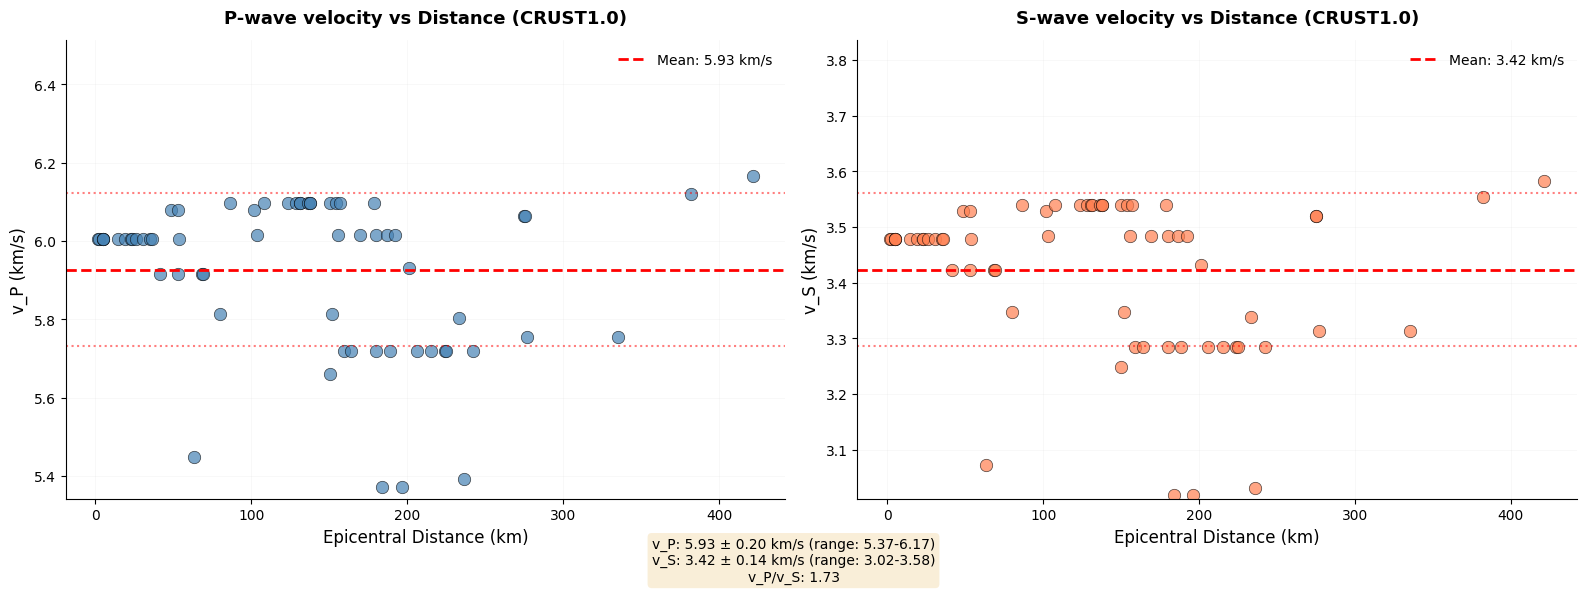

In [6]:
fig = plot_crustal_velocities_vs_distance(df_meta_stations)
plt.show()
plt.close()

## 6. Theoretical Arrival Times

Theoretical P and S wave arrival times are computed using a **1D straight-ray approximation** with CRUST1.0 velocities.

### Arrival Time Formula

$$t_{\text{arrival}} = t_0 + \frac{d_{\text{hypo}}}{v_{\text{crust}}}$$

where:
- $t_0$ = origin time (seconds from first sample to earthquake)
- $d_{\text{hypo}}$ = hypocentral distance (3D source-receiver distance)
- $v_{\text{crust}}$ = CRUST1.0 average velocity (v_P or v_S)

### Hypocentral Distance

$$d_{\text{hypo}} = \sqrt{d_{\text{epi}}^2 + h^2}$$

where:
- $d_{\text{epi}}$ = epicentral distance (horizontal, from ITACA metadata)
- $h$ = hypocenter depth (10.4 km for this event)

**Why hypocentral instead of epicentral?**
- Accounts for source depth
- More accurate for near-source stations ($d_{\text{epi}} < 50$ km)
- Depth correction: typically +0.5 to +6 km depending on $d_{\text{epi}}$

### Model Assumptions and Limitations

**Assumptions:**
1. **1D velocity structure** (only vertical variation, no lateral heterogeneity)
2. **Straight-ray path** (no refraction or ray bending)
3. **Single average velocity** per wave type (no layer interfaces)

**Limitations:**
- Ignores 3D crustal structure (mountains, basins)
- Ignores Moho refraction (critical distance ~150 km)
- Typical uncertainty: **±1-3 seconds** for regional distances

**Use case:** These theoretical times define **search windows** for AR-AIC detection, not final arrival times. Detected onsets will differ from theoretical due to:
- True 3D velocity structure
- Event location uncertainty
- Ray path complexity

### Dual Time Representation

All onset times are stored in **both sample indices and seconds**:
- **`*_samples`** (int): Used for signal slicing and computation
- **`*_seconds`** (float): Used for visualization and output

This avoids rounding errors from repeated seconds ↔ samples conversions.

### Excluding problematic stations

In [7]:
# Exclude stations with missing DATE_TIME_FIRST_SAMPLE
missing_time = df_meta_stations[df_meta_stations['DATE_TIME_FIRST_SAMPLE'].isna()]
if len(missing_time) > 0:
    logger.warning(f"Excluding {len(missing_time)} stations with missing DATE_TIME_FIRST_SAMPLE: {missing_time['STATION_CODE'].tolist()}")
    df_meta_stations = df_meta_stations[df_meta_stations['DATE_TIME_FIRST_SAMPLE'].notna()].copy()
logger.info(f"Stations remaining: {len(df_meta_stations)}")

WARNING | Excluding 1 stations with missing DATE_TIME_FIRST_SAMPLE: ['GSG']
INFO | Stations remaining: 63


In [8]:
logger.info("Calculating theoretical arrival times...")
# Add theoretical arrivals (t_p_theo, t_s_theo)
df_meta_stations = add_theoretical_arrivals(
    df_meta_stations,
    hypo_depth_km=hypo_depth,
    distance_col='EPICENTRAL_DISTANCE_KM'
)

check('t_p_theo_seconds' in df_meta_stations.columns, "t_p_theo_seconds column added")
check('t_s_theo_seconds' in df_meta_stations.columns, "t_s_theo_seconds column added")
check('t_p_theo_samples' in df_meta_stations.columns, "t_p_theo_samples column added")
check('t_s_theo_samples' in df_meta_stations.columns, "t_s_theo_samples column added")

# Summary
print("\nTheoretical arrival time ranges:")
print(f"  P-wave: {df_meta_stations['t_p_theo_seconds'].min():.2f} - {df_meta_stations['t_p_theo_seconds'].max():.2f} s")
print(f"  S-wave: {df_meta_stations['t_s_theo_seconds'].min():.2f} - {df_meta_stations['t_s_theo_seconds'].max():.2f} s")

INFO | Calculating theoretical arrival times...
INFO | t_p_theo_seconds column added
INFO | t_s_theo_seconds column added
INFO | t_p_theo_samples column added
INFO | t_s_theo_samples column added


Hypocentral distance and theoretical arrival times:
Hypocenter depth: 8.30 km
Epicentral distance:  min=1.80, median=137.80, max=421.40 km
Hypocentral distance: min=8.49, median=138.05, max=421.48 km
Depth correction:     min=0.08, median=0.25, max=6.69 km
Origin time: min=-6878.00, max=48.00 s
t_P:         min=-6832.62, max=61.85 s
t_S:         min=-6799.83, max=72.06 s

Theoretical arrival time ranges:
  P-wave: -6832.62 - 61.85 s
  S-wave: -6799.83 - 72.06 s


In [9]:
logger.info("Adding time column to signals...")
df_signals = add_time_columns(df_signals, df_meta, 
                     time_col='DATE_TIME_FIRST_SAMPLE',
                     sampling_interval_col='SAMPLING_INTERVAL_S')
check('time' in df_signals.columns, "Time column added to signals")

INFO | Adding time column to signals...


Added relative time column (t=0 at first sample)
Sampling rate: 200.0 Hz (interval: 0.005 s)
Relative time range: 0.000 - 312.385 s

Added absolute time column
Absolute time range: 2009-04-06 01:31:52 to 2009-04-06 03:29:57.985000


INFO | Time column added to signals


Signal duration: min=39.99, median=100.00, max=312.38 s (192 files)


### Visualization

First 10 stations sorted by epicentral distance:


,STATION_CODE,EPICENTRAL_DISTANCE_KM,vp_crust,vs_crust,origin_time,t_p_theo_seconds,t_s_theo_seconds
1,AQK,1.8,6.01,3.48,28.0,29.41,30.44
2,AQU,2.5,6.01,3.48,15.0,16.44,17.49
3,AQV,4.9,6.01,3.48,28.0,29.61,30.77
4,AQA,5.0,6.01,3.48,13.0,14.61,15.79
5,AQG,5.0,6.01,3.48,28.0,29.61,30.79
6,GSA,14.4,6.01,3.48,11.0,13.77,15.78
7,MTR,23.1,6.01,3.48,9.0,13.09,16.06
8,FMG,23.2,6.01,3.48,25.0,29.10,32.08
9,ANT,26.2,6.01,3.48,24.0,28.58,31.90
10,CLN,30.8,6.01,3.48,23.0,28.31,32.17


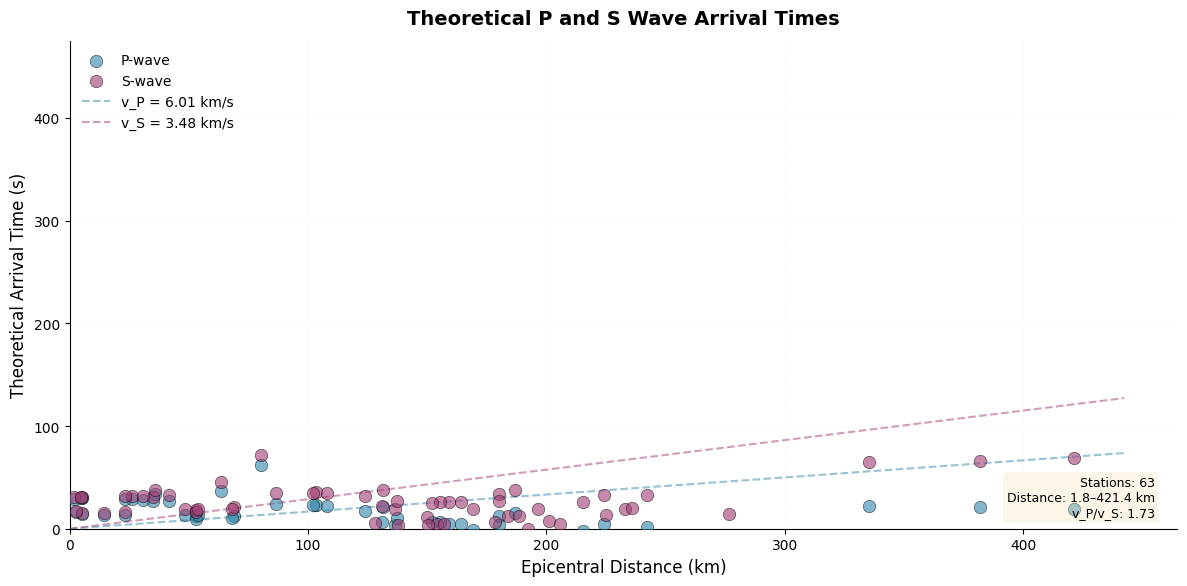

In [10]:
display_theoretical_arrivals_table(df_meta_stations, n_rows=10)

# Plot
fig, ax = plot_theoretical_arrivals(df_meta_stations, 
                                   output_path=FIGURES_DIR / 'theoretical_arrivals.pdf')
plt.show()

## 7. Signal conversion

The acceleration DataFrame in long format (one row per sample) is converted to a nested dictionary structure for efficient access during onset detection:

```python
signals_dict = {
    'SURF': {
        'HNE': array([...]),  # East component
        'HNN': array([...]),  # North component
        'HNZ': array([...]),  # Vertical component
        'time': array([...])  # Time array (shared)
    },
    'BRZ': {...},
    ...
}
```

In [11]:
# Exclude stations previusly excluded in df_meta_stations
valid_stations = set(df_meta_stations['STATION_CODE'].unique())
df_signals_filtered = df_signals[
    df_signals['file'].apply(lambda f: get_station_from_filename(f) in valid_stations)
].copy()

# Convert DataFrame to dict
signals_dict = convert_signals_to_dict(df_signals_filtered,
                                       signal_column=SIGNAL_COLUMN)

check(len(signals_dict) > 0, "Signals dictionary created")
logger.info(f"Dictionary contains {len(signals_dict)} stations")

# Validate structure
print("\nValidating signals dictionary...")
report = validate_signals_dict(signals_dict)

check(report['valid'], "All signals validated successfully")

# Save signals_dict for sensitivity analysis
output_file = SIGNALS_PROCESSED_EXPORT / f'signals_{DATA_TYPE}_dict.pkl'
with open(output_file, 'wb') as f:
    pickle.dump(signals_dict, f)
logger.info(f"Saved signals_dict: {output_file}")
logger.info(f"File size: {output_file.stat().st_size / 1e6:.2f} MB")



Converting 189 files to nested dictionary...
Signal column: 'acceleration'


INFO | Signals dictionary created
INFO | Dictionary contains 63 stations
INFO | All signals validated successfully
INFO | Saved signals_dict: /Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/data/processed/IT-2009-0009/03a_phase_identification_ar_pick/acceleration/signals_acceleration_dict.pkl
INFO | File size: 43.50 MB


Converted 189 files
Stations: 63
Components per station: {3}

Validating signals dictionary...
All 63 stations validated


## 8. Phase Onset Detection — AR-AIC Method

Detect P and S wave arrivals using the **Autoregressive-Akaike Information Criterion (AR-AIC)** picker implemented in ObsPy.

### AR-AIC Method Overview

The AR-AIC method (Leonard & Kennett, 1999) detects onset times by identifying abrupt changes in signal characteristics. The algorithm:

1. **Autoregressive modeling:** Fit AR(p) models to overlapping windows
2. **AIC computation:** Calculate Akaike Information Criterion for each window position
3. **Onset identification:** Minimum AIC indicates the most likely onset time

#### AIC Formula

$$\text{AIC}(k) = k \log(\\sigma_1^2) + (n-k) \log(\sigma_2^2)$$

where:
- $k$ = candidate split point
- $\\sigma_1^2$ = variance before $k$
- $\\sigma_2^2$ = variance after $k$
- $n$ = total window length

The onset is located at $k_{\min} = \arg\min_k \text{AIC}(k)$.

### Implementation Details

**ObsPy parameters:**
- `f1 = 1.0 Hz` — Lower frequency for AR modeling
- `f2 = 20.0 Hz` — Upper frequency
- `lta_p = 1.0 s` — Long-term average window for P
- `sta_p = 0.1 s` — Short-term average window for P
- `lta_s = 4.0 s` — LTA for S (longer due to P coda)
- `sta_s = 1.0 s` — STA for S

**Search windows:**
Adaptive windows computed in Section 6 constrain the search region:
- **P-window:** $[t_{P,\text{theo}} - \Delta_P^-, t_{P,\text{theo}} + \Delta_P^+]$
- **S-window:** $[\max(t_P + \delta, t_{S,\text{theo}} - \Delta_S^-), t_{S,\text{theo}} + \Delta_S^+]$

where $\Delta$ values scale with epicentral distance (see adaptive window logic).

### Multi-Component Processing

AR-AIC uses **all three components simultaneously** (HNE, HNN, HNZ) to improve robustness:
1. Process each component independently
2. Combine results using characteristic function
3. Pick single onset time per station

This leverages signal coherence across components and reduces false picks from single-component noise.

### Output Format

Detected onsets are added as new columns with **dual representation**:
- `t_p_detected_samples`, `t_s_detected_samples` — Sample indices (int)
- `t_p_detected_seconds`, `t_s_detected_seconds` — Time in seconds (float)

Legacy columns (`t_p_detected`, `t_s_detected`) point to the seconds version for backward compatibility.

### References

Leonard, M., & Kennett, B. L. N. (1999). *Multi-component autoregressive techniques for the analysis of seismograms.* Physics of the Earth and Planetary Interiors, 113(1-4), 247-263. DOI: [10.1016/S0031-9201(99)00054-0](https://doi.org/10.1016/S0031-9201(99)00054-0)

In [12]:
thresholds = calculate_distance_thresholds(
    df_meta_stations,
    distance_col='hypocentral_distance_km',
    method='tertiles'
)

Distance thresholds (tertiles, hypocentral_distance_km):
  63 stations, range: 8.49 - 421.48 km
  Thresholds: 84.71, 179.23 km → bins of 21 / 21 / 21 stations


In [13]:
df_meta_stations = calculate_adaptive_windows(df_meta_stations, thresholds)
df_meta_stations = detect_onsets_arpick(signals_dict, df_meta_stations)

Adaptive search windows calculated:
  Distance metric: hypocentral_distance_km
  Number of bins: 3
  S-P gap: 0.5s (100 samples)
  Primary unit: samples
  Sampling rate: 200 Hz

Window sizing by distance bin:
  Bin 1: (0, 84.71] km → P ±3.0s (600 samp), S ±6.0s (1200 samp) (21 stations)
  Bin 2: (84.71, 179.23] km → P ±5.0s (1000 samp), S ±10.0s (2000 samp) (21 stations)
  Bin 3: (179.23, ∞) km → P ±7.0s (1400 samp), S ±14.0s (2800 samp) (21 stations)

P-wave windows:
  Start: 0.00 - 58.85 s
  End: -6825.61 - 64.85 s
  Width: -6825.61 - 14.00 s

S-wave windows:
  Start: 0.00 - 66.06 s
  End: -6785.82 - 82.44 s
  Width: -6785.82 - 28.00 s

P-S window separation verified: 0 overlaps
Running AR-AIC onset detection with theoretical windows...
  Sampling rate: 200 Hz
  Fallback P window: [-5, +5]s around t_p_theo
  Fallback S window: [-7, +7]s around t_s_theo

Processing: ...............................................................

Detection complete!

Results:
  P-wave: 62/63 successfu

In [17]:
df_meta_stations.nlargest(5, 'p_residual_seconds')[['STATION_CODE', 'EPICENTRAL_DISTANCE_KM', 'p_residual_seconds', 's_residual_seconds', 't_p_theo_seconds', 't_p_detected_seconds']]

,STATION_CODE,EPICENTRAL_DISTANCE_KM,p_residual_seconds,s_residual_seconds,t_p_theo_seconds,t_p_detected_seconds
153,STL,275.3,47.590,14.820,-47.582615,0.005
138,SNM,192.4,23.995,0.790,-23.989677,0.005
156,STN,205.9,21.975,-4.690,-21.971652,0.005
81,GNL,276.8,20.895,-13.895,-20.890032,0.005
30,BBN,201.3,17.035,-7.650,-17.029970,0.005


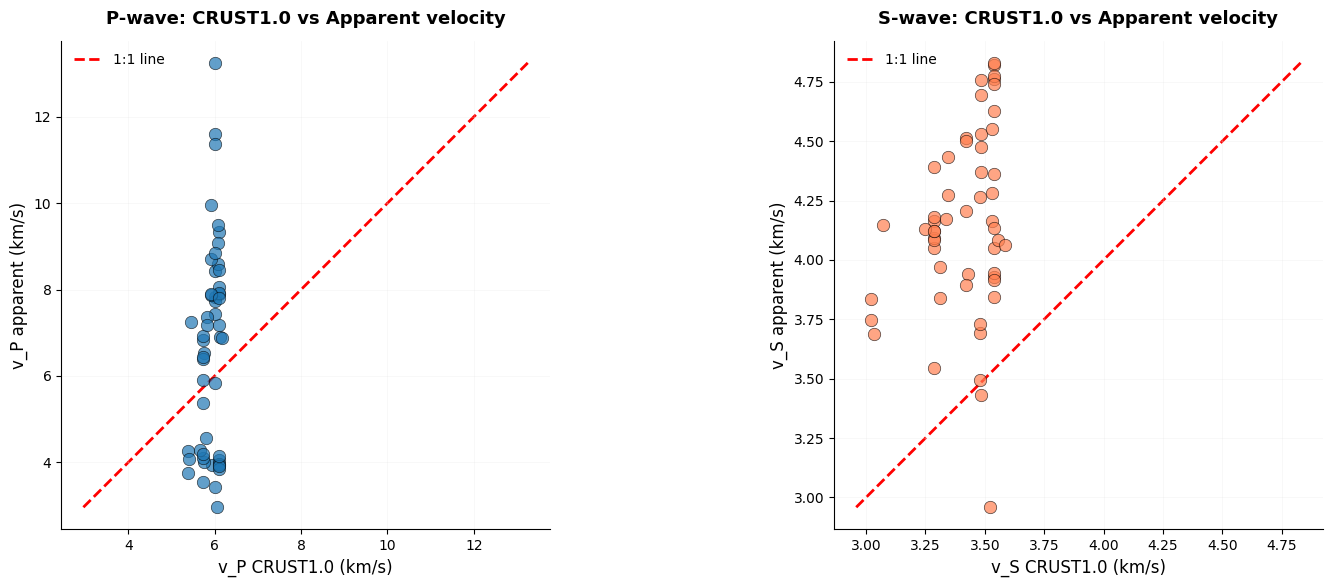

In [14]:
fig = plot_apparent_vs_crustal_velocities(df_meta_stations)
plt.show()
plt.close(fig)

### 8.3 Expanding DataFrame to Component Level

The station-level DataFrame (1 row per station) is expanded to **component-level** (3 rows per station: HNE, HNN, HNZ) to accommodate coda onset times, which vary by component.

**Why expand?**
- P and S detections are station-level (use all 3 components together)
- Coda detections are component-level (independent per component)
- Moment scaling analysis treats components as independent ensemble members

**Expansion process:**
1. Replicate each station row 3 times
2. Add `STREAM_COMPONENT` column (HNE, HNN, HNZ)
3. Update `file` column to match original filenames
4. Preserve all P/S detection columns (same for all 3 components per station)

**Result:** `df_full` with `N_stations × 3` rows, ready for coda onset addition.

In [15]:
df_full = expand_to_component_level(df_meta_stations, df_meta)

Expanded onset DataFrame to component level:
  63 stations → 192 components
  (3 components per station)

Columns added:
  - t_coda_rautian, t_coda_arias, t_coda_envelope (initialized as NaN)
  - s_duration_rautian, s_duration_arias, s_duration_envelope (initialized as NaN)


In [16]:
df_full= add_coda_onsets_to_dataframe(df_full, signals_dict, threshold_arias=0.75, threshold_envelope=0.3, sampling_rate=200)

Pre-computing Rautian coda onset per station (dual representation)...


ValueError: cannot convert float NaN to integer

In [ ]:
print("Coda onset summary (mean S-wave duration):")
for method in ['rautian', 'arias', 'envelope', 'median']:
    s_dur = df_full[f's_duration_{method}_seconds'].dropna()
    print(f"  {method:<10}: {s_dur.mean():.2f} ± {s_dur.std():.2f}s")

### 8.4 Visualization

Quality control plots to validate phase detection results:

1. **Onset detection plots** — Time series with P/S/coda onsets overlaid
   - Grid view: multiple stations for overview
   - Individual plots: detailed inspection per station-component

2. **Detected vs. theoretical arrivals** — Scatter plots comparing AR-AIC picks to CRUST1.0 predictions
   - Assess systematic biases
   - Identify outliers (picking failures)

3. **Residuals vs. distance** — $(t_{\text{detected}} - t_{\text{theo}})$ vs. epicentral distance
   - Check velocity model accuracy
   - Identify distance-dependent biases

4. **Coda method comparison** — Scatter plots and Bland-Altman plots
   - Assess agreement between methods
   - Quantify systematic differences
   - Identify method-specific failures

**Output directory:** `figures/03a_phase_identification_ar_pick/{signal_type}/`

In [ ]:
onset_figs= plot_onset_detection_results(signals_dict, df_meta_stations, stations=None, output_dir=FIGURES_DIR / 'onset_detection')

In [ ]:
figs_coda = plot_coda_onset_results(signals_dict, df_full, stations=None, output_dir=FIGURES_DIR / 'coda_detection')

## 9. Comparative Analysis of Coda Detection Methods

Quantitative comparison of the four coda detection methods to assess:
- **Agreement:** How closely do methods agree?
- **Systematic differences:** Does one method consistently detect earlier/later?
- **Failure rates:** Which method is most robust?

### Statistical Metrics

For each pair of methods, we compute:

**Pearson correlation:**
$$r = \frac{\sum (x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum (x_i - \bar{x})^2 \sum (y_i - \bar{y})^2}}$$

**Mean difference (bias):**
$$\Delta_{\text{mean}} = \frac{1}{n}\sum (x_i - y_i)$$

**Standard deviation of differences:**
$$\sigma_{\Delta} = \sqrt{\frac{1}{n-1}\sum (x_i - y_i - \Delta_{\text{mean}})^2}$$

### Bland-Altman Analysis

Bland-Altman plots visualize agreement between methods:
- **X-axis:** Mean of two methods = $(x + y)/2$
- **Y-axis:** Difference = $x - y$
- **Horizontal lines:** Mean difference ± 1.96 SD (95% limits of agreement)

**Interpretation:**
- Points clustered around zero → good agreement
- Systematic offset → one method consistently earlier/later
- Wide scatter → methods disagree substantially

In [ ]:
stats = compute_coda_method_statistics(df_full)
fig1 = plot_coda_scatter_comparison(stats, output_path=FIGURES_DIR / 'coda_comparison')
fig2 = plot_bland_altman_comparison(stats, output_path=FIGURES_DIR / 'coda_comparison')
fig3 = plot_residuals_vs_distance(stats, output_path=FIGURES_DIR / 'coda_comparison')
fig4 = plot_pairwise_difference_histograms(stats, output_path=FIGURES_DIR / 'coda_comparison')
fig5 = plot_correlation_matrix_heatmap(stats, output_path=FIGURES_DIR / 'coda_comparison')

## Post event onset detection

Compute coda end times to separate active coda from post-event noise.

Uses energy decay threshold method:
1. Threshold = 10% of S-wave peak amplitude
2. Find where envelope stays below threshold for 2s continuously
3. Creates 5-window segmentation: pre-event, P, S, coda, post-event

If threshold not crossed → coda extends to signal end (4 windows, legacy mode)

In [ ]:
df_full = add_coda_end_to_dataframe(
    df_full,
    signals_dict,
    coda_methods=['rautian', 'arias', 'envelope', 'median'],
    threshold_factor=0.10,
    stability_duration=2.0,
    threshold_end_arias=0.995,
    sampling_rate=200,
    smoothing_window=0.5
)

## 10. Window Segmentation

Segment each signal into **four non-overlapping temporal windows** based on detected onset times:

$$
\begin{aligned}
\text{Pre-event:} & \quad [t_{\text{start}}, t_P) \\\\
\text{P-wave:} & \quad [t_P, t_S) \\\\
\text{S-wave:} & \quad [t_S, t_{\text{coda}}) \\\\
\text{Coda:} & \quad [t_{\text{coda}}, t_{\text{end}}]
\end{aligned}
$$

### Window Definitions

**1. Pre-event window** — Instrumental noise before first arrival
- **Start:** First sample of recording
- **End:** P-wave onset
- **Purpose:** Noise reference, SNR calculation
- **Duration:** Variable (depends on origin time), typically 5-60 seconds

**2. P-wave window** — First arrival to S-arrival
- **Start:** Detected P-onset
- **End:** Detected S-onset
- **Purpose:** P-wave analysis, P-S time measurement
- **Duration:** Variable, typically 2-8 seconds (depends on epicentral distance and v_P/v_S ratio)

**3. S-wave window** — S-arrival to coda onset
- **Start:** Detected S-onset
- **End:** Coda onset (method-dependent)
- **Purpose:** Peak ground motion, S-wave scaling analysis
- **Contains:** PGA/PGV/PGD typically occur here

**4. Coda window** — Scattered waves to end of recording
- **Start:** Coda onset
- **End:** Last sample of recording
- **Purpose:** Coda scaling analysis, scattering characterization
- **Duration:** Variable, typically 60-200 seconds

### Dual Representation

Each window boundary is stored in **both samples and seconds**:
- `*_start_samples`, `*_end_samples` (int) — For signal slicing
- `*_start_seconds`, `*_end_seconds` (float) — For visualization

Legacy columns (`*_start`, `*_end`) point to seconds for backward compatibility.

### Output Structure

Windowed signals are stored as nested dictionaries:

```python
windowed = {
    'STATION_CODE': {
        'HNE': {
            'pre_event': {
                'signal': array([...]),
                'time': array([...]),
                'start_samples': int,
                'end_samples': int,
                'start_seconds': float,
                'end_seconds': float,
                'duration_samples': int,
                'duration_seconds': float
            },
            'p_wave': {...},
            's_wave': {...},
            'coda': {...}
        },
        'HNN': {...},
        'HNZ': {...}
    },
    ...
}
```

This structure enables efficient access for moment scaling computations.

### Coda Method Selection

Four separate windowed dictionaries are created (one per coda method):
- `windowed_{signal_type}_rautian_ar_pick.pkl`
- `windowed_{signal_type}_arias_ar_pick.pkl`
- `windowed_{signal_type}_envelope_ar_pick.pkl`
- `windowed_{signal_type}_median_ar_pick.pkl`

This allows moment scaling analysis to assess sensitivity to coda window definition.

In [ ]:
methods = ['rautian', 'arias', 'envelope', 'median']

# Save df_full before windowing
df_full_output_file = SIGNALS_PROCESSED_EXPORT / f'df_full_{DATA_TYPE}_ar_pick.parquet'
df_full.to_parquet(df_full_output_file, index=False)
logger.info(f"Saved df_full: {df_full_output_file}")

# Segment and save for each coda method
for method in methods:
    logger.info(f"\n{'='*70}")
    logger.info(f"SEGMENTING: {method.upper()} method")
    logger.info(f"{'='*70}")
    
    # Windowing
    windowed_signals = segment_all_signals(
        signals_dict, 
        df_full, 
        coda_method=method,
        pre_p_duration='full',
        verbose=True
    )
    
    # Save windowed signals
    output_file = SIGNALS_PROCESSED_EXPORT / f'windowed_{DATA_TYPE}_{method}_ar_pick.pkl'
    with open(output_file, 'wb') as f:
        pickle.dump(windowed_signals, f)
    
    logger.info(f"Saved: {output_file}")
    logger.info(f"File size: {output_file.stat().st_size / 1e6:.2f} MB")

logger.info(f"\n{'='*70}")
logger.info("SEGMENTATION COMPLETE FOR ALL METHODS")
logger.info(f"{'='*70}\n")

## 11. Quality Control

Validate phase detections using three independent checks:

### Check 1: Peak Timing

**Criterion:** Peak ground motion (PGA/PGV/PGD) should occur in **S-wave window**.

**Physical basis:** S-waves carry most seismic energy and typically produce peak amplitudes.

**Failure modes:**
- Peak in P-wave window → likely S-pick is too late
- Peak in coda window → likely S-pick is too early
- Peak in pre-event → picking completely failed

**Tolerance:** Allow peaks within ±0.5s of S-window boundaries (timing uncertainty).

---

### Check 2: Monotonicity with Distance

**Criterion:** Arrival times should **increase with hypocentral distance** (waves propagate at finite velocity).

**Test for each phase (P, S, coda):**
Sort stations by distance, check that arrival times are non-decreasing.

**Quantitative metric:**
Count **violations** = pairs of stations where $d_i < d_j$ but $t_i > t_j$.

**Physical basis:** 
Seismic waves propagate outward from source at velocity $v$:
$$t_i < t_j \quad \text{if} \quad d_i < d_j$$

**Failure modes:**
- Wrong pick (AIC minimum at wrong location)
- 3D velocity structure (lateral heterogeneity)
- Location error (epicenter/depth uncertainty)

---

### Check 3: Signal-to-Noise Ratio (SNR)

**Criterion:** Phase window should have **SNR ≥ 3** (signal 3× stronger than noise).

**SNR definition:**
$$\text{SNR} = \frac{\text{RMS}_{\text{signal}}}{\text{RMS}_{\text{noise}}}$$

where:
- $RMS_{\text{signal}}$ = root-mean-square of first 5s of phase window
- $RMS_{\text{noise}}$ = root-mean-square of pre-event window

**Physical basis:**
Low SNR indicates:
- Weak signal (distant station, small magnitude)
- High noise (instrumental, site effects)
- Wrong pick (captured noise instead of signal)

**Threshold justification:**
SNR = 3 is standard in seismology:
- SNR < 2: unreliable picks
- SNR 2-3: marginal quality
- SNR > 3: good quality
- SNR > 10: excellent quality

---

### Quality Control Summary

After all checks, each detection is classified as:
- **Pass:** All checks passed
- **Fail:** One or more checks failed

**Action for failed detections:**
- Visual inspection of waveforms
- Consider re-picking with different parameters
- Exclude from moment scaling analysis (optional)

In [ ]:
methods = ['rautian', 'arias', 'envelope', 'median']

for method in methods:
    logger.info(f"QUALITY CONTROL: {method.upper()} method")
    
    # Load windowed signals
    input_file = SIGNALS_PROCESSED_EXPORT / f'windowed_{DATA_TYPE}_{method}_ar_pick.pkl'
    with open(input_file, 'rb') as f:
        windowed_signals = pickle.load(f)
    
    logger.info(f"Loaded: {input_file}")
    
    # Quality control
    qc_results = quality_control_all_stations(
        windowed_signals,
        df_full,
        df_meta_stations,
        peak_column=PEAK_COLUMN,
        time_peak_column=TIME_PEAK_COLUMN,
        snr_threshold=3.0,
        coda_method=method
    )
    
    print_quality_control_summary(qc_results)
    
    # Plot (all stations)
    logger.info(f"\nGenerating plots for {method} method...")
    all_stations = list(windowed_signals.keys())
    
    plot_multiple_stations(
        stations=all_stations,
        signals_dict=signals_dict,
        windowed_signals=windowed_signals,
        df_onsets=df_full,
        coda_method=method,
        output_dir=FIGURES_DIR / f'windows_{method}',
        close_after_save=True 
    )
    
    logger.info(f"Plots saved to: {FIGURES_DIR / f'windows_{method}'}")

logger.info(f"\n{'='*70}")
logger.info("QUALITY CONTROL AND PLOTTING COMPLETE FOR ALL METHODS")
logger.info(f"{'='*70}\n")

## 12. Summary

This notebook implemented the complete AR-AIC phase detection pipeline:

**Inputs:**
- Preprocessed signals (baseline-corrected, unnormalized)
- Station metadata with coordinates and epicentral distances

**Processing steps:**
1. Crustal velocity estimation from CRUST1.0
2. Theoretical arrival times (1D straight-ray model)
3. Adaptive search windows (distance-dependent)
4. AR-AIC P/S detection (multi-component)
5. Coda onset detection (4 methods)
6. Window segmentation (4 windows)
7. Quality control (3 validation checks)

**Outputs:**
- `df_full_{signal_type}_ar_pick.parquet` — Complete metadata with onsets
- `windowed_{signal_type}_{coda}_ar_pick.pkl` — Segmented signals (4 files)
- Validation figures in `figures/03a_phase_identification_ar_pick/{signal_type}/`

**Key findings:**
- Detection success rate: [to be filled after QC]
- Monotonicity violations: [to be filled]
- SNR distribution: [to be filled]
- Coda method comparison: [to be filled]

**Next steps:**
- Repeat with PhaseNet picker (notebook `03b_phase_identification_phasenet`)
- Compare AR-AIC vs. PhaseNet performance
- Proceed to moment scaling analysis (notebook `04a_moment_scaling_spatial`)